## rx1day - central coast

In [1]:
import glob

import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import numpy as np

from unseen import process_utils
from unseen import eva

In [2]:
#from importlib import reload

In [3]:
#reload(eva)

In [4]:
region = 'Central Coast (NSW)'

In [5]:
ds = xr.open_dataset('/g/data/xv83/unseen-projects/outputs/pasha/data/rx1day_AGCD-CSIRO_1901-2024_YE-AUG_pasha-lgas.nc')
ds = ds.sel(region=region)

In [6]:
ds

<xarray.Dataset> Size: 7kB
Dimensions:     (time: 124)
Coordinates:
    region      <U19 76B 'Central Coast (NSW)'
  * time        (time) datetime64[ns] 992B 1901-01-01 1902-01-01 ... 2024-01-01
    event_time  (time) <U10 5kB ...
Data variables:
    pr          (time) float32 496B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2025-02-06 02:46:57
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2025, ...
    history:                   Wed Sep 03 13:42:55 2025: /g/data/xv83/dbi599/...

In [7]:
df = ds.to_dataframe()
df.index = df.index.year

In [8]:
df

,pr,region,event_time
time,,,
1901,47.638420,Central Coast (NSW),1901-03-16
1902,37.045547,Central Coast (NSW),1901-10-11
1903,100.024391,Central Coast (NSW),1902-10-13
1904,105.790421,Central Coast (NSW),1904-07-09
1905,87.297318,Central Coast (NSW),1905-04-02
...,...,...,...
2020,128.053879,Central Coast (NSW),2020-02-08
2021,109.423691,Central Coast (NSW),2021-03-21
2022,113.815994,Central Coast (NSW),2022-07-05


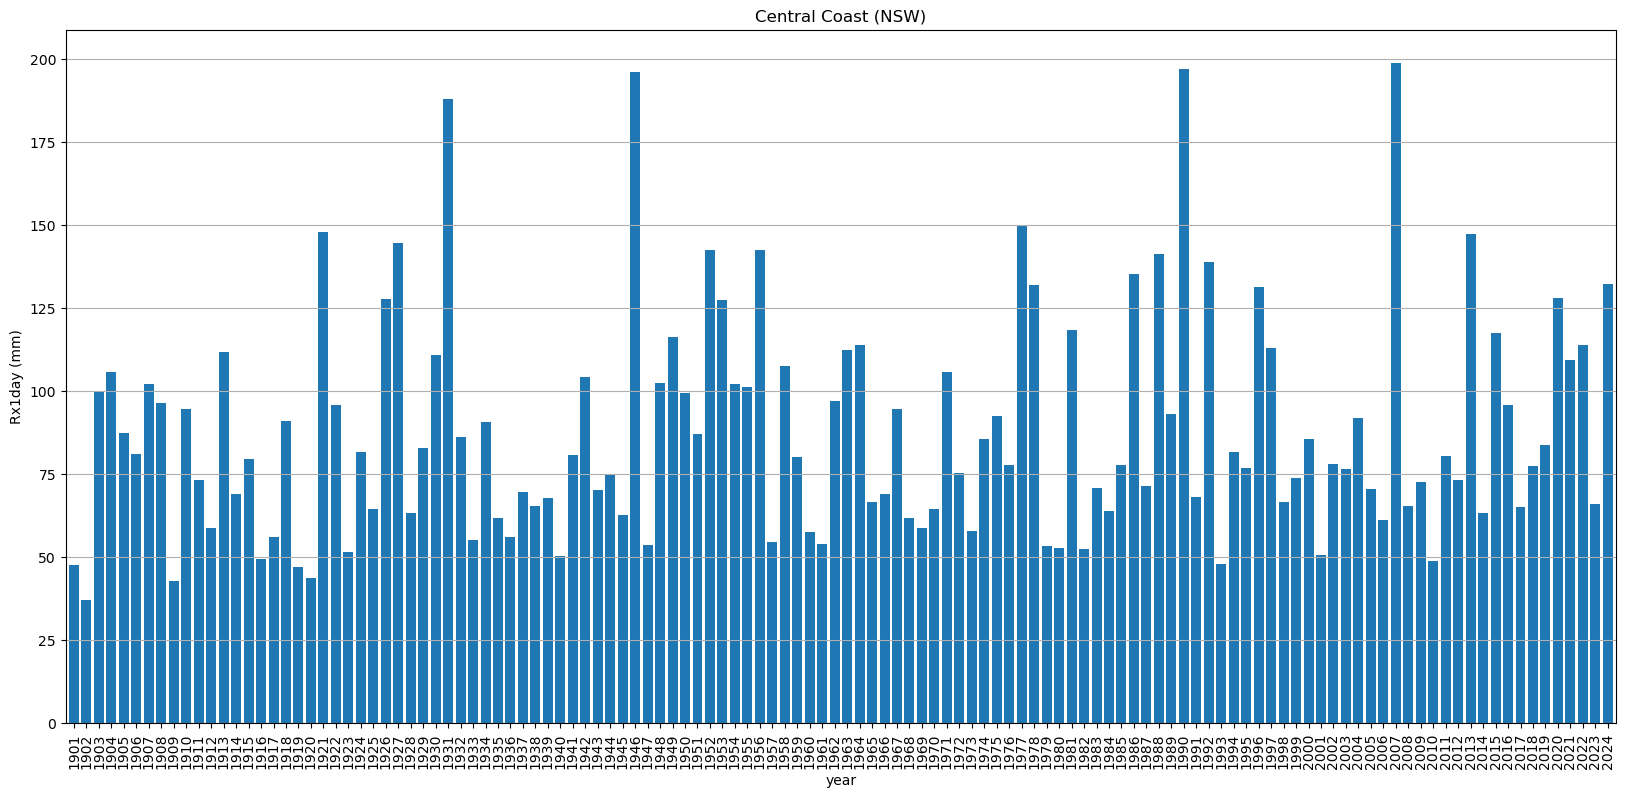

In [9]:
df['pr'].plot.bar(figsize=[20, 9], width=0.8)
plt.ylabel('Rx1day (mm)')
plt.xlabel('year')
plt.title(region)
plt.grid(axis='y')
plt.show()

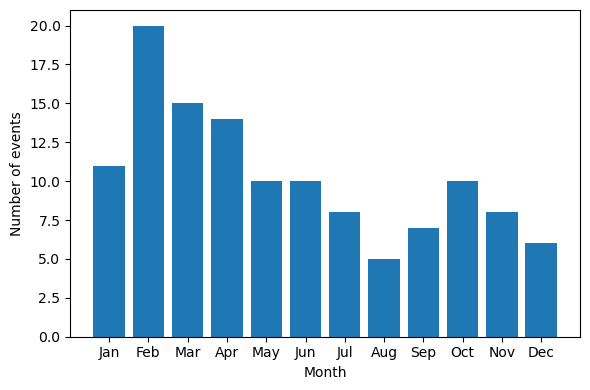

In [10]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
process_utils.plot_event_seasonality(ds, ax=ax)
plt.show()

In [11]:
ranked_years = df.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

              pr               region  event_time
time                                             
2007  198.793991  Central Coast (NSW)  2007-06-09
1990  197.021866  Central Coast (NSW)  1990-02-03
1946  196.175583  Central Coast (NSW)  1946-04-16
1931  188.166321  Central Coast (NSW)  1931-07-07
1977  149.735748  Central Coast (NSW)  1977-03-04
1921  147.824234  Central Coast (NSW)  1920-12-10
2013  147.252045  Central Coast (NSW)  2013-01-29
1927  144.614380  Central Coast (NSW)  1927-04-16
1952  142.677780  Central Coast (NSW)  1952-07-26
1956  142.650162  Central Coast (NSW)  1956-02-10


In [12]:
rx1day_2007 = float(ds['pr'].sel(time='2007-01-01').values)
rx1day_2007

198.7939910888672

In [13]:
dparams_s = eva.fit_gev(ds['pr'])

In [14]:
dparams_s

<xarray.DataArray 'pr' (dparams: 3)> Size: 24B
array([-0.12639586, 71.83579712, 23.10523713])
Coordinates:
    region   <U19 76B 'Central Coast (NSW)'
  * dparams  (dparams) <U8 96B 'c' 'location' 'scale'
Attributes:
    long_name:    Genextreme parameters
    description:  Parameters of the genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

In [15]:
dparams_ns = eva.fit_gev(
    ds['pr'],
    stationary=False,
    covariate=ds['time'],
    pick_best_model=True
)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),


In [16]:
dparams_ns

<xarray.DataArray (dparams: 5)> Size: 40B
array([-1.61919579e-01,  7.21895179e+01,  2.79691037e-04,  2.42383018e+01,
        5.50129946e-06])
Coordinates:
    region   <U19 76B 'Central Coast (NSW)'
  * dparams  (dparams) <U10 200B 'c' 'location_0' ... 'scale_0' 'scale_1'
Attributes:
    long_name:    Nonstationary genextreme parameters
    description:  Parameters of the nonstationary genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


65 year return period
95% CI: 35-315 years


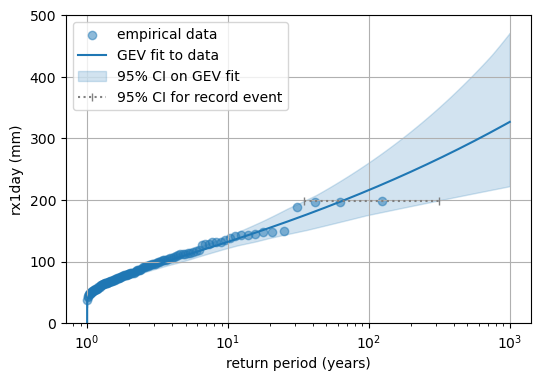

In [18]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    ds['pr'].values,
    rx1day_2007,
    direction="exceedance",
    bootstrap_method='parametric',
    n_bootstraps=100,
    max_return_period=3,
    ylabel='rx1day (mm)',
    ylim=(0, 500),
)
plt.show()

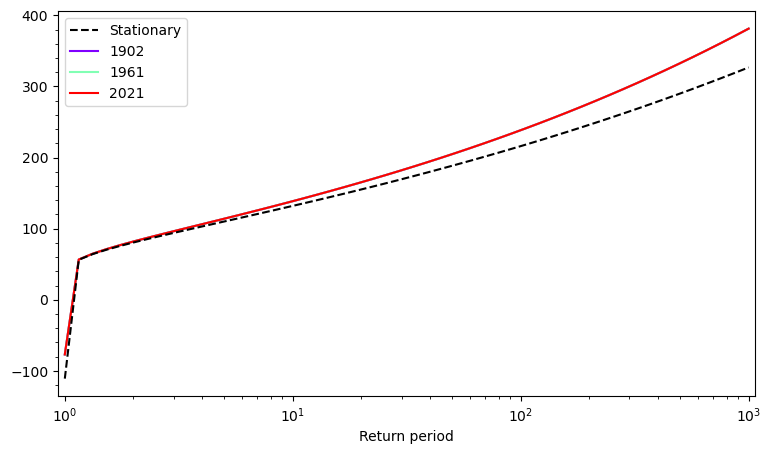

In [19]:
eva.plot_nonstationary_return_curve(
    xr.DataArray(np.logspace(0, 3)),
    dparams_s,
    dparams_ns,
    ds['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()

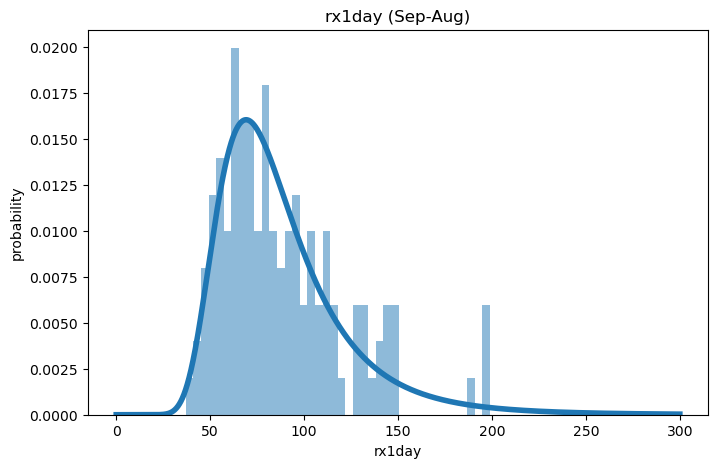

In [20]:
fig, ax = plt.subplots(figsize=[8, 5])
gev_xvals = np.arange(0, 300, 0.1)
shape, loc, scale = dparams_s

ds['pr'].plot.hist(bins=40, density=True, color='tab:blue', alpha=0.5)
pdf = gev.pdf(gev_xvals, shape, loc, scale)
plt.plot(gev_xvals, pdf, color='tab:blue', linewidth=4.0, label='AGCD')

plt.xlabel('rx1day')
plt.ylabel('probability')
plt.title(f'rx1day (Sep-Aug)')
#plt.xlim(xmin, xmax)
plt.show()

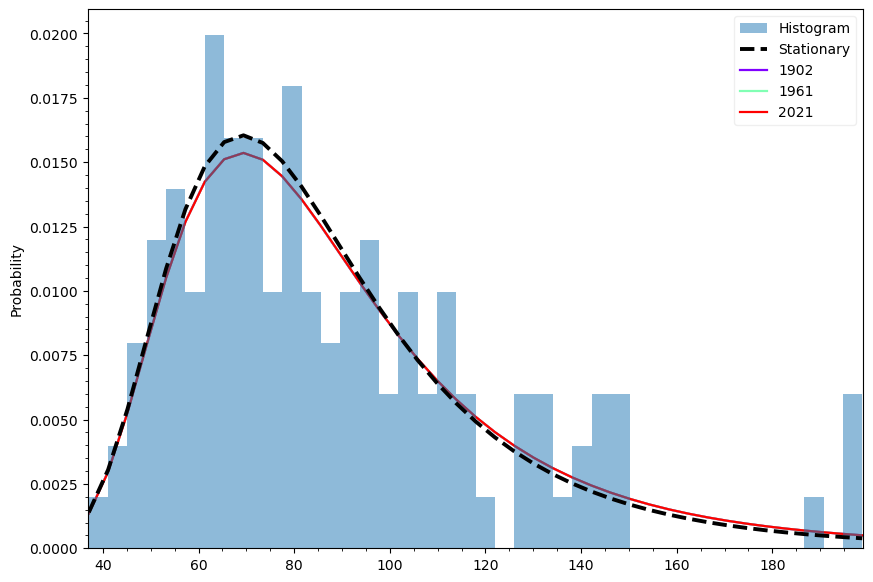

In [21]:
eva.plot_nonstationary_pdfs(
    ds['pr'],
    dparams_s,
    dparams_ns,
    ds['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()